# Topic 1: Statistics & Probability for Detection

**Module:** CITY2161 Data Modelling and Machine Learning for Cyber Security
**Workshop:** Topic 1 studio workshop, completed in Python with hand working shown where the workshop asks for it.

## What this notebook is for

Every intrusion detector, from a simple threshold rule to a machine-learning model, rests on three statistical questions. This workshop answers each one on the module dataset:

| Part | Question | Statistical idea | Why a detection engineer cares |
|---|---|---|---|
| A | What is normal? | Summary statistics: mean, median, quartiles, percentiles, histograms | You cannot spot unusual traffic until you can describe usual traffic. |
| B | How surprising is it? | Tail probabilities by counting vs. by a model (Poisson) | A threshold is only useful if you know how often normal traffic crosses it. |
| C | Given an alert, is it an attack? | Base rates, Bayes' theorem with counts, precision | Rare attacks plus a small false-alarm rate produce mostly false alerts. |
| D | Checking many hosts at once | Hypothesis tests, p-values, multiple-comparison corrections | Testing 1,000 hosts guarantees false alarms unless you correct for it. |
| Stretch | Better corrections and better models | Benjamini-Hochberg, negative binomial | Match the correction to the analysts' capacity and the model to the data. |

## The data

`cyberlab.py` (from the Lab Kit) simulates a small enterprise network: 60 hosts observed for 120 hours, aggregated to one row per host per hour, giving 7,200 host-hours. Each row has six numeric features (`n_flows`, `n_distinct_ports`, `n_distinct_dsts`, `total_bytes`, `mean_duration`, `failed_logins`), one categorical feature (`top_service`) and a label: `label` is 1 when the alerting system raised a true-attack alert in that hour (a port scan, data exfiltration or SSH brute force) and 0 otherwise. About 6.6% of host-hours are labelled as attacks, which is hundreds of times richer than a real network, a fact that matters in Part C.

Two columns must never be used as features: `n_alerts` is the label in disguise, and `true_kind` (only with `return_truth=True`) is the simulation's answer key.

## Setup

The first two lines are the same in every workshop of the module: import the lab module and load the host-hour table. We also import the libraries used throughout: NumPy for arrays and random numbers, pandas for tables, matplotlib for plots, and SciPy's `stats` module for probability distributions and tests.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import cyberlab as C
X = C.load()          # 7,200 host-hours: features, label and metadata

print("rows, columns:", X.shape)
print("attack hours:", int(X.label.sum()), f"({X.label.mean():.1%} of host-hours)")
X.head()

rows, columns: (7200, 12)
attack hours: 472 (6.6% of host-hours)


,host_id,ts,n_flows,n_distinct_ports,n_distinct_dsts,total_bytes,mean_duration,failed_logins,top_service,n_alerts,attack_family,label
0,h000,2024-03-01,21,5,8,61512,0.433927,0,http,0,benign,0
1,h001,2024-03-01,13,5,8,37256,0.458067,0,http,0,benign,0
2,h002,2024-03-01,11,3,7,31383,0.318206,1,http,0,benign,0
3,h003,2024-03-01,2,2,2,5973,0.722664,0,http,0,benign,0
4,h004,2024-03-01,2,2,2,572972,8.418580,0,ssh,0,benign,0


## Part A - What is normal?

Before anything can be called an attack we need a picture of what an ordinary host-hour looks like. Every detection rule in this module is a comparison against "normal", so this part builds that baseline: first by hand on nine numbers so the definitions are clear, then in Python on the 6,728 normal host-hours in the dataset, and finally by sorting the columns into things we can do arithmetic on and things we can only count.

### A.1 On paper: mean, median, range and IQR of nine hours

The nine hours are 21, 5, 47, 25, 14, 13, 14, 8, 22 (n = 9). Working by hand:

1. Sort: 5, 8, 13, 14, 14, 21, 22, 25, 47
2. Sum: 5 + 8 + 13 + 14 + 14 + 21 + 22 + 25 + 47 = 169
3. Mean = 169 / 9 = 18.78 (2 d.p.)
4. Median = the middle (5th) value of the sorted list = 14
5. Range = largest minus smallest = 47 - 5 = 42
6. Lower half, leaving the overall median out: 5, 8, 13, 14. Q1 = median of these = (8 + 13) / 2 = 10.5
7. Upper half, leaving the overall median out: 21, 22, 25, 47. Q3 = median of these = (22 + 25) / 2 = 23.5
8. IQR = Q3 - Q1 = 23.5 - 10.5 = 13

Method used: quartiles as the medians of the two halves with the overall median left out (the halves method). To check against the notes, the four values to compare are mean 18.78, median 14, range 42 and IQR 13. The code cell below reproduces all four from the same nine numbers, and numpy's method="weibull" returns the same quartiles 10.5 and 23.5, so the hand arithmetic is confirmed. The mean, median and range do not depend on any convention, so only the IQR can legitimately differ: a worked example that keeps the overall median in both halves would give Q1 = 13, Q3 = 22 and IQR = 9, which is also what pandas' default prints in the next cell, so a difference there would be the method, not a slip in the working. Notice that one hour (47) pulls the mean (18.78) well above the median (14): the median tells us what a typical hour looks like, while the mean is dragged around by the outlier. That is exactly the situation a detection baseline has to cope with.

The cell below repeats the hand calculation with numpy and pandas. It is for checking our arithmetic and, more importantly, for seeing what pandas does differently: its default quantile() interpolates between positions in the sorted list rather than taking medians of the halves. An analyst who copies a quartile from a tool into a report needs to know which convention produced it, otherwise two people can "compute the IQR" of the same data and set different thresholds.

In [12]:
hours = pd.Series([21, 5, 47, 25, 14, 13, 14, 8, 22])
a_sorted = np.sort(hours.values)
print("sorted:", a_sorted)
print("sum   :", hours.sum())
print("mean  :", round(hours.mean(), 2))
print("median:", hours.median())
print("range :", hours.max() - hours.min())

# hand method: quartiles are the medians of the two halves, overall median left out
a_lower, a_upper = a_sorted[:4], a_sorted[5:]
q1_hand, q3_hand = np.median(a_lower), np.median(a_upper)
print("hand   Q1, Q3, IQR:", q1_hand, q3_hand, q3_hand - q1_hand)

# pandas default ('linear'): quantile p sits at zero-indexed position (n-1)*p in the sorted
# list, interpolating only if that position is fractional (here 2 and 6 are whole, so it is not)
a_q = hours.quantile([0.25, 0.75])
print("pandas Q1, Q3, IQR:", a_q[0.25], a_q[0.75], a_q[0.75] - a_q[0.25])
print("pandas interpolation='midpoint':", hours.quantile([0.25, 0.75], interpolation="midpoint").values)
print("numpy  method='weibull'        :", np.percentile(hours, [25, 75], method="weibull"))

sorted: [ 5  8 13 14 14 21 22 25 47]
sum   : 169
mean  : 18.78
median: 14.0
range : 42
hand   Q1, Q3, IQR: 10.5 23.5 13.0
pandas Q1, Q3, IQR: 13.0 22.0 9.0
pandas interpolation='midpoint': [13. 22.]
numpy  method='weibull'        : [10.5 23.5]


The code agrees with the hand working on the mean (18.78), median (14.0) and range (42). For the quartiles the hand method gives Q1 = 10.5, Q3 = 23.5, IQR = 13, while pandas gives Q1 = 13.0, Q3 = 22.0, IQR = 9.0, exactly as the workshop hint warned. The difference is the convention: pandas puts Q1 at position (n - 1) x 0.25 = 2 and Q3 at position (n - 1) x 0.75 = 6 in the zero-indexed sorted list, which land exactly on the values 13 and 22, so no interpolation is even needed here; that is also why interpolation="midpoint" returns the same 13 and 22. The hand method instead takes the median of the four values on each side of the overall median. For interest, numpy's method="weibull" (positions (n + 1) x p) happens to reproduce the hand values 10.5 and 23.5 on these nine numbers. Both conventions are acceptable as long as we say which one we used: we used the halves method on paper and pandas' default in code.

### A.2 In Python: the normal host-hours

The cell below keeps only the host-hours with label == 0 (no true alert fired) and summarises n_flows, the number of network flows a host produced in an hour. It prints the median, the quartiles and the 95th and 99th percentiles, plus the count, mean and maximum, how many normal hours exceed each of the top two percentiles, and how many sit beyond the right edge of the histogram we plot next. For a detection engineer these percentiles are candidate alert thresholds: the 99th percentile of normal traffic is the level that only about 1 in 100 quiet hours reaches, so a rule that fires above it has a known, small false-alarm rate before we have even looked at an attack. One caveat to carry through the whole part: label == 0 only means no true alert fired. The cyberlab.py docstring says the labelling detector misses about 15% of attack hours, so a few of these "normal" hours, especially the very busiest, are really undetected attacks; Topic 10 measures that label noise. The Series flows is defined here and reused in later parts.

In [13]:
flows = X.loc[X.label == 0, "n_flows"]      # normal host-hours only
print(flows.median(), flows.quantile([0.25, 0.75, 0.95, 0.99]))
print("count:", flows.count(), " mean:", round(flows.mean(), 2), " max:", flows.max())
for a_pct in (0.95, 0.99):
    a_thr = flows.quantile(a_pct)
    a_above = flows > a_thr
    print(f"normal hours above the {int(round(a_pct * 100))}th percentile ({a_thr:.0f} flows):",
          a_above.sum(), "=", round(100 * a_above.mean(), 2), "%")
print("normal hours above 100 flows (off the right edge of the histogram):",
      (flows > 100).sum(), "=", round(100 * (flows > 100).mean(), 2), "%")

11.0 0.25     6.0
0.75    18.0
0.95    45.0
0.99    60.0
Name: n_flows, dtype: float64
count: 6728  mean: 14.8  max: 174
normal hours above the 95th percentile (45 flows): 325 = 4.83 %
normal hours above the 99th percentile (60 flows): 66 = 0.98 %
normal hours above 100 flows (off the right edge of the histogram): 24 = 0.36 %


Across the 6,728 normal host-hours the median is 11 flows and the middle half of hours lie between Q1 = 6 and Q3 = 18 flows (IQR 12). The tail is long: the 95th percentile is 45 flows, the 99th is 60, and the busiest label-0 hour has 174 flows, so the mean (14.8) sits above the median because a few busy hours drag it up. Only 24 label-0 hours (0.36%) exceed 100 flows and so fall off the histogram below, which is why cutting the axis at 100 is an honest choice; given the label noise mentioned above, hours that extreme are exactly where undetected attacks are likely to be hiding, so the far tail of this baseline is probably longer than a truly quiet host would produce. Read as thresholds: "flag hours above 60 flows" (strictly more than 60; Part B counts hours at or above a threshold, which adds the hours sitting exactly on it) would still raise 66 alarms out of 6,728 label-0 hours (0.98%, close to the 1% the 99th percentile promises), while "flag above 45" would raise 325 (4.83%), about five times as many. Whichever we choose, the cost is a predictable number of alarms per day, and that trade-off is the subject of Part C.

The histogram puts the same numbers in a picture: one bar per band of 5 flows, height = number of normal host-hours in that band. It is the shape an analyst should carry in their head when reading an alert (is 40 flows a lot?), and it also shows whether the distribution is symmetric, so that mean and standard deviation are safe summaries, or skewed with a long tail, so that medians and percentiles are safer.

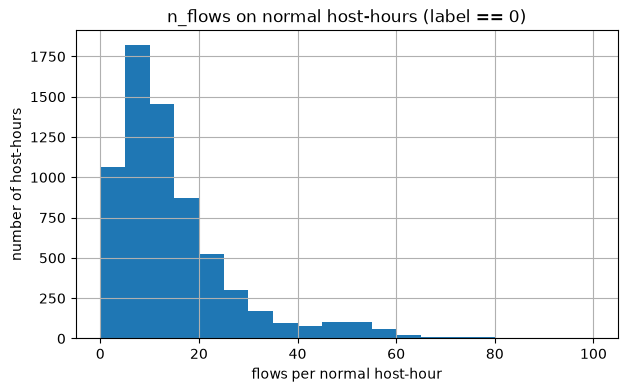

In [14]:
plt.figure(figsize=(7, 4))
flows.hist(bins=range(0, 105, 5))
plt.xlabel("flows per normal host-hour")
plt.ylabel("number of host-hours")
plt.title("n_flows on normal host-hours (label == 0)")
plt.show()

The distribution is strongly right-skewed. The tallest bar is the 5 to 9 flows band with about 1,800 hours, roughly three quarters of normal hours sit below 20 flows, and the bars shrink steadily out to 60 and are almost empty beyond 65, apart from a small secondary bump around 45 to 55 flows (the "busy admin" hours that cyberlab.py builds into the benign traffic). There is no symmetric bell here, so the median and percentiles from the printout describe a normal hour far better than the mean and standard deviation would. Anything to the right of 60 is rare for a label-0 hour, and rarer still for a genuinely quiet host once the undetected attacks are discounted; that rarity is exactly what a threshold is meant to capture.

### A.3 Count/measurement or category?

| column | type | what it holds | a calculation that would be meaningless |
|---|---|---|---|
| n_flows | count (numeric, whole numbers) | flows in the hour | - |
| total_bytes | measurement (numeric; a byte total on so fine a scale that it is treated as continuous) | bytes transferred in the hour | - |
| failed_logins | count (numeric, whole numbers) | failed login attempts in the hour | - |
| top_service | category (nominal label: http, ssh, dns, smtp, other) | the commonest service in the hour | the mean of top_service (or its standard deviation or a z-score): "http plus ssh divided by two" has no meaning |

The distinction matters because everything in Parts B and D (means, standard deviations, z-scores, Poisson counts) assumes numbers with an order and a scale. A category has neither: http is not "more" than ssh. What we can do with a category is count how often each value appears, compare those proportions between normal and attack hours, or turn it into 0/1 indicator columns later in the module. The cell below shows the meaningful calculation (a count of each value) and confirms that pandas refuses the meaningless one.

In [15]:
a_svc = X.top_service.value_counts()        # counting IS meaningful on a category
try:
    X.top_service.mean()                    # averaging is NOT
except TypeError as e:
    print("X.top_service.mean() ->", type(e).__name__ + ":", e)
pd.DataFrame({"host_hours": a_svc, "share": (a_svc / len(X)).round(3)})

X.top_service.mean() -> TypeError: Cannot perform reduction 'mean' with string dtype


,host_hours,share
top_service,,
http,5993,0.832
other,553,0.077
ssh,415,0.058
dns,178,0.025
smtp,61,0.008


http is the top service in 5,993 of the 7,200 host-hours (83.2%), followed by other (553, 7.7%), ssh (415, 5.8%), dns (178, 2.5%) and smtp (61, 0.8%). Asking pandas for the mean raises a TypeError saying it cannot take the mean of a string column (the exact wording depends on the pandas version; on this one it is "Cannot perform reduction 'mean' with string dtype"), which is the library telling us the same thing the table does. For detection the counts are already useful: a host whose top service is ssh is in a 6% minority and worth a second look, while Part B's Poisson tail probabilities and Part D's z-tests can only be applied to the numeric columns.

### A.4 Heavy tails: summarise with medians

To close, the cell below compares the median of each numeric feature between normal and attack hours, prints the median and 99th percentile of total_bytes across all hours, and counts how many normal hours record at least one failed login. This previews why the rest of the module keeps reaching for medians and percentiles rather than means: security counts have heavy tails, one backup or one bulk transfer can be a hundred times the typical hour, and a summary that is dragged by such hours makes a poor baseline.

In [16]:
a_num = ["n_flows", "n_distinct_ports", "n_distinct_dsts",
         "total_bytes", "mean_duration", "failed_logins"]
a_med = X.groupby("label")[a_num].median().T.round(2)
a_med.columns = ["normal (label 0)", "attack (label 1)"]
a_tb = X.total_bytes
print("total_bytes, all hours: median", round(a_tb.median()),
      " 99th percentile", round(a_tb.quantile(0.99)),
      " ratio", round(a_tb.quantile(0.99) / a_tb.median(), 1))
a_fl = X.loc[X.label == 0, "failed_logins"] > 0
print("normal hours with at least one failed login:", a_fl.sum(), "=", round(100 * a_fl.mean(), 1), "%")
a_med

total_bytes, all hours: median 42824  99th percentile 3463089  ratio 80.9
normal hours with at least one failed login: 777 = 11.5 %


,normal (label 0),attack (label 1)
n_flows,11.00,67.00
n_distinct_ports,4.00,55.00
n_distinct_dsts,6.00,40.00
total_bytes,44946.50,8473.00
mean_duration,0.56,0.06
failed_logins,0.00,0.00


The medians separate the two classes cleanly on the scan-shaped features: a typical attack hour has 67 flows against 11 for a normal hour, touches 55 distinct ports against 4, and 40 distinct destinations against 6. total_bytes goes the other way (median 8,473 for attack hours against 44,946.5 for normal ones) because half of the attacks are port scans made of tiny packets. failed_logins has a median of 0 in both classes: ordinary hours record the odd failed login (777 normal hours, about 11.5%, have at least one) but only the brute-force family produces them in bulk, and brute force is under a quarter of the attack hours, so the attack-class median is 0 too. A median can hide a feature that matters for one family only, which is worth remembering. On total_bytes the heavy tail is stark: the median over all hours is 42,824 bytes but the 99th percentile is 3,463,089, about 81 times larger; these are the same two figures the Lab Kit quotes (42,824 and 3,463,089). A mean of such a column is a poor description of a normal hour, which is why this part, and the rest of the module, summarises with medians and percentiles.

**Portfolio capture**

Hand working (nine hours 21, 5, 47, 25, 14, 13, 14, 8, 22): sorted 5, 8, 13, 14, 14, 21, 22, 25, 47; sum 169; mean 169 / 9 = 18.78; median 14; range 47 - 5 = 42; Q1 = (8 + 13) / 2 = 10.5 and Q3 = (22 + 25) / 2 = 23.5 using medians of the halves with the overall median excluded, so IQR = 23.5 - 10.5 = 13. pandas' default interpolating method gives Q1 = 13.0, Q3 = 22.0, IQR = 9.0; both are acceptable and we have stated which we used.

Percentile printout for n_flows on the 6,728 normal (label-0) host-hours: median 11.0; 25th percentile 6.0; 75th 18.0; 95th 45.0; 99th 60.0; mean 14.8; maximum 174; 66 hours (0.98%) exceed the 99th percentile and 24 (0.36%) exceed 100 flows. Because the labelling detector misses about 15% of attack hours, some of those extreme label-0 hours are probably undetected attacks.

Histogram: strongly right-skewed, peak in the 5 to 9 flows band (about 1,800 hours), bars shrinking steadily out to about 60 flows with a small bump near 45 to 55, only 29 hours between 65 and 99 plus one at exactly 100, and 24 hours off the chart above 100.

What a normal hour looks like: a normal host-hour has about 11 flows (half of them between 6 and 18, fewer than 1% above 60), goes mostly to http, moves around 45,000 bytes and typically records no failed logins.

## Part B - How surprising is it?

Part A showed the shape of n_flows in normal host-hours: most hours have a handful of flows and a few have a lot. An alert rule needs more than a shape; it needs a number for "how often does normal traffic reach this level?". That number is a tail probability, P(n_flows at least T), and there are two ways to get it: count it directly from the normal hours we have (empirical), or assume a probability model (Poisson) and read it off the formula. This part does both and checks whether they agree, because whichever one we use decides how many false alarms an analyst will see.

### B.1 Tail probability by counting

For each threshold T in 30, 45, 60 and 100 flows the code counts how many normal hours have n_flows at or above T and divides by the number of normal hours. The comparison (flows >= T) gives a True/False Series, and because True counts as 1, its mean is exactly the share of hours above the threshold. This is probability by counting: no model, just the fraction of past normal hours that would have fired the rule.

We also turn each share into "1 in N" and into expected false alarms per day. This network has 60 hosts x 24 hours = 1,440 host-hours a day, almost all of them normal, so share x 1440 is roughly how many benign hours per day would trip the rule (a slight overestimate, because about 7% of a day's host-hours are attack hours rather than benign, but close enough for a rough count). The share is what the notes tabulate, but false alarms per day is the number an analyst actually feels, because each one is a ticket somebody has to close.

In [17]:
thresholds = [30, 45, 60, 100]
n_normal = len(flows)
rows = []
for T in thresholds:
    share = (flows >= T).mean()      # True counts as 1, so the mean is the share
    rows.append({"threshold": T,
                 "normal hours at or above": int((flows >= T).sum()),
                 "share of normal hours": round(share, 4),
                 "1 in N": round(1 / share),
                 "false alarms per day (share x 1440)": round(share * 1440, 1)})
threshold_table = pd.DataFrame(rows)
print("normal host-hours:", n_normal)
threshold_table

normal host-hours: 6728


,threshold,normal hours at or above,share of normal hours,1 in N,false alarms per day (share x 1440)
0,30,686,0.1020,10,146.8
1,45,342,0.0508,20,73.2
2,60,74,0.0110,91,15.8
3,100,25,0.0037,269,5.4


There are 6,728 normal host-hours. A threshold of 30 flows is reached by 686 of them, a share of 0.102 (about 1 in 10), which would mean roughly 147 false alarms a day, far too many to triage. At 45 flows the share is 0.0508 (1 in 20, about 73 a day); at 60 it is 0.011 (1 in 91, about 16 a day); and even at 100 flows 25 normal hours qualify, a share of 0.0037 (1 in 269), still about 5 false alarms a day. Notice that doubling the threshold from 30 to 60 cuts false alarms by about 9x, but going from 60 to 100 only cuts them by another 3x: the tail thins out slowly.

Comparison with Table 2 of the notes: the rows to set beside the table are the counts 686, 342, 74 and 25 and the shares 0.1020, 0.0508, 0.0110 and 0.0037 for thresholds 30, 45, 60 and 100 (Table 2 is in the lecture notes and is not reproduced here). The notes are computed from the same cyberlab.py and seed, so they should agree to the digit; if a row disagrees, the most likely cause is that flows was built from all hours instead of the normal (label == 0) hours only.

### B.2 The busiest host-hour, and what a flow-count rule would catch

X.n_flows.idxmax() gives the row index of the host-hour with the most flows in the whole dataset (attacks included), and X.loc pulls that row out so we can see who it was, when, and whether it was labelled an attack. We then count how many normal hours reached that many flows, and also list every host-hour at or above 175 flows (one more than the busiest normal hour) to see what a rule set just above all normal traffic would actually fire on. The point is to see where the record sits relative to normal traffic: if the biggest hour is an attack that no normal hour comes close to, a rule near that level would be very safe but would only ever catch extreme cases.

In [18]:
top = X.loc[X.n_flows.idxmax()]
print(top[["host_id", "ts", "n_flows", "label", "attack_family"]])
print("normal hours with at least", top.n_flows, "flows:", int((flows >= top.n_flows).sum()))
print("busiest normal hour:", int(flows.max()), "flows")
print("host-hours in the whole dataset with at least 175 flows:", int((X.n_flows >= 175).sum()))
X.loc[X.n_flows >= 175, ["host_id", "ts", "n_flows", "label", "attack_family"]]

host_id                         h030
ts               2024-03-04 05:00:00
n_flows                          182
label                              1
attack_family               portscan
Name: 4650, dtype: object
normal hours with at least 182 flows: 0
busiest normal hour: 174 flows
host-hours in the whole dataset with at least 175 flows: 2


,host_id,ts,n_flows,label,attack_family
2013,h033,2024-03-02 09:00:00,175,1,portscan
4650,h030,2024-03-04 05:00:00,182,1,portscan


The record is host h030 at 2024-03-04 05:00 with 182 flows, and it was an attack (label 1, attack_family portscan). No normal hour reached 182 flows, so this one is unambiguous. But the busiest normal hour is not far behind at 174 flows (a ground-truth aside at the end of B.2 will show that this hour is itself an attack the label missed), so the gap between attacks and genuinely benign traffic is wider than the label suggests. A rule set at "more than any normal hour we have seen" (T = 175) would fire on just two host-hours in the whole dataset, this one and a 175-flow portscan on h033 at 2024-03-02 09:00, and nothing else. That is the trade-off in miniature: a threshold high enough to never false-alarm is also high enough to miss almost everything.

To see that trade-off properly we score the simple rule "alert if n_flows >= T" on both sides at once. The false-alarm share is the fraction of normal hours the rule fires on (the same numbers as B.1); the detection rate is the fraction of attack hours (label == 1) the rule fires on. A detection engineer never looks at one of these without the other, because any threshold can make one of them look good. Part C turns this pair into the numbers that matter at the SOC screen.

In [19]:
attack = X.loc[X.label == 1, "n_flows"]
tradeoff = pd.DataFrame({
    "threshold": thresholds,
    "false-alarm share (normal hours >= T)": [round((flows >= T).mean(), 4) for T in thresholds],
    "detection rate (attack hours >= T)": [round((attack >= T).mean(), 4) for T in thresholds],
})
print("attack host-hours:", len(attack))
tradeoff

attack host-hours: 472


,threshold,false-alarm share (normal hours >= T),detection rate (attack hours >= T)
0,30,0.1020,0.7585
1,45,0.0508,0.6822
2,60,0.0110,0.5720
3,100,0.0037,0.2775


There are 472 attack hours. Raising the threshold from 30 to 100 cuts the false-alarm share from 0.102 to 0.0037 (about 27x fewer false alarms) but the detection rate falls from 0.7585 to 0.2775, so we would miss almost three attacks in four. At the middle setting of 45 flows the rule catches 68% of attack hours while firing on 5% of normal ones; at 60 it catches 57% for 1.1%. Note that even the loosest threshold only reaches 76% detection: about a quarter of the attack hours have fewer than 30 flows, so no flow-count threshold can find them. The next table shows which family they belong to.

Here we split the attack hours by attack_family and score the T = 45 rule inside each family (caught is True when the hour has at least 45 flows). This matters because "detection rate" averaged over all attacks can hide a family that a feature is completely blind to, and a rule that misses a whole class of attack is a rule the attacker will learn to exploit.

In [20]:
att = X.loc[X.label == 1]
by_family = (att.assign(caught=att.n_flows >= 45)
                .groupby("attack_family")
                .agg(attack_hours=("caught", "size"),
                     caught=("caught", "sum"),
                     detection_rate=("caught", "mean"),
                     median_n_flows=("n_flows", "median"),
                     max_n_flows=("n_flows", "max"))
                .round(3))
by_family

,attack_hours,caught,detection_rate,median_n_flows,max_n_flows
attack_family,,,,,
bruteforce,110,72,0.655,52.0,88
exfil,112,0,0.000,4.0,9
portscan,250,250,1.000,102.5,182


At T = 45 the rule catches every portscan hour (250 of 250, median 102.5 flows) and 72 of the 110 bruteforce hours (65.5%, median 52 flows), but 0 of the 112 exfiltration hours. Exfiltration here is a few large transfers: its median is 4 flows and its busiest hour has only 9, well inside normal. So n_flows is a good feature for scans, a fair one for bruteforce, and useless for exfil, which would need a bytes-based rule instead (total_bytes, with its heavy tail, is the feature for that). A flow-count detector on its own leaves the most damaging family completely uncovered.

Aside: the label comes from alerts, and cyberlab.py documents that its labelling detector misses about 15% of attack hours, which is exactly how a real alert-derived label behaves. C.load(return_truth=True) returns the same rows with an extra column true_kind saying what the host really did. Here we look at what the 74 "normal" hours with 60 or more flows really were, and at the five busiest hours the label calls normal. This is not a feature we could use in practice (we never know the truth), but it tells us how much of the false-alarm share in B.1 is genuine benign traffic and how much is label noise.

In [21]:
XT = C.load(return_truth=True)       # same 7,200 rows plus true_kind
noisy = XT.loc[(XT.label == 0) & (XT.n_flows >= 60), "true_kind"].value_counts()
print(noisy)
# the five busiest hours the label calls normal, and what they really were
XT.loc[XT.label == 0].nlargest(5, "n_flows")[["host_id", "ts", "n_flows", "true_kind"]]

true_kind
portscan      38
benign        22
bruteforce    14
Name: count, dtype: int64


,host_id,ts,n_flows,true_kind
3969,h009,2024-03-03 18:00:00,174,portscan
6321,h021,2024-03-05 09:00:00,159,portscan
746,h026,2024-03-01 12:00:00,157,portscan
2701,h001,2024-03-02 21:00:00,156,portscan
6613,h013,2024-03-05 14:00:00,153,portscan


Of the 74 labelled-normal hours with 60+ flows, 38 were unlabelled portscans and 14 were unlabelled bruteforce attempts; only 22 were genuinely benign, mostly busy-admin hours plus a few ordinary hours at the far end of their own spread (true_kind cannot tell those two apart). The five busiest labelled-normal hours (153 to 174 flows, on h009, h021, h026, h001 and h013) are all unlabelled portscans. So the "1 in 91" false-alarm share at 60 flows is partly the label's fault, not the rule's: the rule was right about those 52 hours and the label was wrong. We keep using the label as given, because that is what a real SOC has, but it is worth remembering when Part C treats every alert on a label-0 hour as a false alarm. Topic 10 returns to this.

### B.3 Does a Poisson model fit?

A Poisson distribution is the standard model for counts of independent events at a steady rate, and it has one parameter, the mean, which also equals its variance. So the first check is free: compare the variance of normal n_flows with its mean. If the ratio is about 1 a Poisson might fit; if it is far above 1 the data are overdispersed and a single Poisson cannot describe them. Then we ask the Poisson model for P(at least 60) using stats.poisson.sf(59, mean) (sf is the survival function, P(X > 59)) and set it beside the counted share from B.1. If the two disagree badly, an alert rule built on the model would be calibrated to a fantasy.

In [22]:
share = (flows >= 60).mean()      # True counts as 1, so the mean is the share
print("counted:", round(share, 4))
print("mean", round(flows.mean(), 2), "variance", round(flows.var(), 2))
print("variance-to-mean ratio:", round(flows.var() / flows.mean(), 2))
print("Poisson says:", stats.poisson.sf(59, flows.mean()))   # sf(59) is P(at least 60)

counted: 0.011
mean 14.8 variance 204.62
variance-to-mean ratio: 13.83
Poisson says: 9.724699823755378e-19


The mean is 14.8 flows but the variance is 204.62, a variance-to-mean ratio of 13.83. A Poisson would have a ratio of 1, so the variance of normal n_flows is about 14 times what a Poisson with this mean allows (a standard deviation about 3.7 times larger): strongly overdispersed. The consequence shows in the tail. The Poisson model says P(at least 60) is 9.7e-19, about 1 in a billion billion, so in our 6,728 normal hours it expects to see 60+ flows essentially never. We counted 74 such hours, a share of 0.011 (1 in 91). The model is wrong by a factor of about 10^16 at exactly the place where an alert rule lives.

The same comparison at all four thresholds shows how the gap grows with the threshold. The code adds two columns to the B.1 threshold table: the Poisson tail P(at least T), computed as sf(T - 1) with the same mean, and the ratio of the counted share to the Poisson value. Reading the ratio column is the quickest way to see that a bad model does not fail by a little; it fails by more the further out you go, which is exactly where thresholds are set.

In [23]:
mu = flows.mean()
counted = np.array([(flows >= T).mean() for T in thresholds])
poisson_tail = np.array([stats.poisson.sf(T - 1, mu) for T in thresholds])
threshold_table["Poisson P(at least T)"] = [f"{v:.2g}" for v in poisson_tail]
threshold_table["counted / Poisson"] = [f"{v:.2g}" for v in counted / poisson_tail]
threshold_table

,threshold,normal hours at or above,share of normal hours,1 in N,false alarms per day (share x 1440),Poisson P(at least T),counted / Poisson
0,30,686,0.1020,10,146.8,0.00034,3e+02
1,45,342,0.0508,20,73.2,2.1e-10,2.4e+08
2,60,74,0.0110,91,15.8,9.7e-19,1.1e+16
3,100,25,0.0037,269,5.4,5e-48,7.5e+44


At 30 flows the counted share (0.102) is already about 300 times the Poisson value (0.00034); at 45 the model gives 2.1e-10 against a counted 0.0508, a factor of 2.4e+08; at 60 the factor is 1.1e+16; and at 100 the Poisson tail is 5e-48, which is zero for every practical purpose, against a counted 1 in 269 (factor 7.5e+44). The model gets worse exponentially as the threshold rises, so the further we push a threshold to be "safe", the more misleading a Poisson-based false-alarm estimate becomes.

Now we draw the two distributions on top of each other: a density histogram of normal n_flows in bins of 5 (density=True makes the bar heights comparable with a probability mass function), with the Poisson pmf for the same mean drawn as a line, and the 60-flow threshold marked. A picture makes the overdispersion obvious in a way the numbers alone do not, and it is the figure to show a colleague who wants to know why we do not just use the textbook formula.

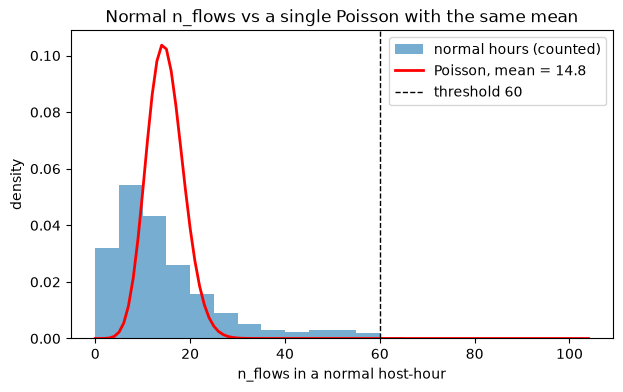

In [24]:
plt.figure(figsize=(7, 4))
plt.hist(flows, bins=range(0, 105, 5), density=True, alpha=0.6, label="normal hours (counted)")
k = np.arange(0, 105)
plt.plot(k, stats.poisson.pmf(k, mu), "r-", lw=2, label=f"Poisson, mean = {mu:.1f}")
plt.axvline(60, color="k", ls="--", lw=1, label="threshold 60")
plt.xlabel("n_flows in a normal host-hour")
plt.ylabel("density")
plt.title("Normal n_flows vs a single Poisson with the same mean")
plt.legend()
plt.show()

The Poisson is a tall narrow bump centred on about 15 (peak density 0.104 at 14 flows) that is effectively zero by 30 flows. The real data peak earlier, in the 5 to 10 bin, and are lower and flatter: a shoulder out to 30, then a thin tail out to 60. The two shapes do not even agree in the middle, let alone in the tail.

Beyond 60 this linear scale hides the tail: the counted bars there are 0.0006 and smaller (one bin, 80 to 85, holds no hours at all), which is invisible next to a peak of 0.104, and the 24 normal hours above 100 flows fall off the right edge because the bins stop at 100. The table above, not this picture, carries the tail comparison. The next figure changes the scale so the tail can be seen.

The same picture on a log scale, with the bins extended to 175 so every normal hour is drawn. On a log axis each factor of 10 takes the same vertical space, so a density of 0.0001 is as visible as 0.1. The floor is set at 1e-5, below the density that a single normal hour contributes (1 / (6728 x 5) = 3e-5), so every bar that appears stands for at least one real hour, and any part of the Poisson line that drops off the bottom is the model saying "this never happens".

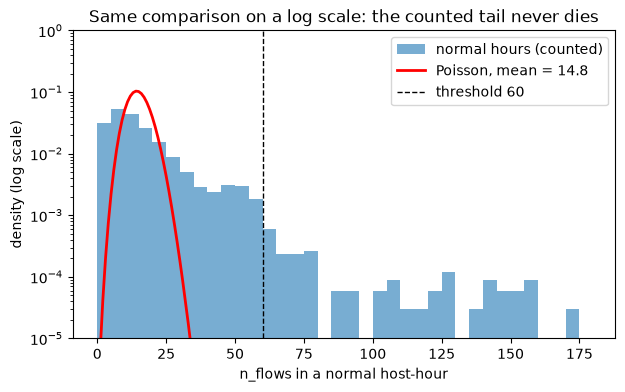

In [25]:
plt.figure(figsize=(7, 4))
plt.hist(flows, bins=range(0, 180, 5), density=True, alpha=0.6, label="normal hours (counted)")
k = np.arange(0, 180)
plt.plot(k, stats.poisson.pmf(k, mu), "r-", lw=2, label=f"Poisson, mean = {mu:.1f}")
plt.axvline(60, color="k", ls="--", lw=1, label="threshold 60")
plt.yscale("log")
plt.ylim(1e-5, 1)
plt.xlabel("n_flows in a normal host-hour")
plt.ylabel("density (log scale)")
plt.title("Same comparison on a log scale: the counted tail never dies")
plt.legend()
plt.show()

On the log scale the disagreement is plain. The Poisson line falls off the bottom of the chart at 34 flows and never comes back: the model says that a normal hour with 35 or more flows is rarer than 1 in 100,000. The counted bars carry on past the 60-flow line at densities of 0.0006 down to 0.00003 all the way to the 170-175 bin (the 174-flow hour), with only a few empty bins in between. Every one of those bars is real normal-labelled traffic the model cannot account for.

The reason is overdispersion: normal hours are not all drawn from one rate. In cyberlab.py every ordinary host-hour first draws its own rate from a Gamma distribution with mean 12 and then draws 1 + a Poisson count at that rate (mean 13), so the rate changes from hour to hour (in the simulation every host is statistically identical; on a real network hosts would differ from each other as well); a mixture of Poissons with different rates is always wider than a single Poisson. On top of that about 4% of benign hours are busy-admin hours built around 50 flows, another 4% are nightly backups with about 5 flows, and (as the aside in B.2 showed) a few unlabelled attacks sit in the tail as well. A single Poisson has no way to represent any of that.

Verdict for an alert rule: trust the counted tail. The Poisson model says 60+ flows in a normal hour is a 1 in 10^18 event, which would make an analyst treat every such hour as a near-certain attack, when in fact it happens in about 1.1% of normal hours (1 in 91), roughly 16 times a day across this network. A model that is off by sixteen orders of magnitude at the threshold is worse than no model, because it hides the false alarms it is supposed to predict. The stretch section (S.2) tries a negative binomial, a count model that lets the variance exceed the mean, as a replacement.

**Portfolio capture**

Threshold table (6,728 normal host-hours; false alarms per day assume 1,440 host-hours checked daily):

| threshold | normal hours at or above | share of normal hours | 1 in N | false alarms per day | Poisson P(at least T) |
|---|---|---|---|---|---|
| 30 | 686 | 0.1020 | 10 | 146.8 | 0.00034 |
| 45 | 342 | 0.0508 | 20 | 73.2 | 2.1e-10 |
| 60 | 74 | 0.0110 | 91 | 15.8 | 9.7e-19 |
| 100 | 25 | 0.0037 | 269 | 5.4 | 5e-48 |

Verdict on the Poisson model: normal n_flows has mean 14.8 but variance 204.6 (ratio 13.8, where a Poisson would give 1), because hosts and hours run at different rates and busy-admin, backup and a few unlabelled attack hours are mixed in, so the data are far more spread out than a single Poisson allows. For an alert rule we trust the counted tail, since the model puts P(at least 60 flows) at 9.7e-19 while we actually observe it in 1.1% of normal hours (1 in 91, about 16 false alarms a day), an error of sixteen orders of magnitude at exactly the level where a threshold would be set.

## Part C - Given an alert, is it an attack?

This is the key deliverable of the topic. A detector is usually advertised by two numbers, how many attacks it catches (detection rate) and how often it fires on normal traffic (false-alarm rate), but the number an analyst actually lives with is a third one: of the alerts that land in the queue, what share are real? That depends just as much on how rare attacks are (the base rate) as on the detector, and this part works out exactly how.

### C.1 On paper: the frequency tree

Detector: catches 95% of attacks, wrongly alerts on 2% of normal host-hours; attacks are 1 in 5,000. Working it as counts for 100,000 host-hours, the way we would draw it on paper:

```
100,000 host-hours
|
|-- attacks: 100,000 / 5,000 = 20
|     |-- caught (alert):    20 x 0.95 = 19
|     +-- missed (no alert): 20 - 19   = 1
|
+-- normal: 100,000 - 20 = 99,980
      |-- false alert: 99,980 x 0.02 = 1,999.6
      +-- quiet:       99,980 - 1,999.6 = 97,980.4
```

Total alerts raised = 19 + 1,999.6 = 2,018.6.
Share of alerts that are real = 19 / 2,018.6 = 0.0094, about 0.9%, so roughly one alert in every 106 is a genuine attack.

This is Bayes' theorem done with counts instead of probabilities: the share of alerts that are real is P(attack | alert), also called the positive predictive value or precision of the detector. The trap of assuming a "95% accurate" detector gives 95%-trustworthy alerts is the base-rate fallacy. It happens because 2% of a huge number of normal hours (1,999.6) is far more than 95% of a tiny number of attacks (19), so the alert queue is swamped by false alarms.

The code below reproduces each branch of the tree with the same arithmetic so we can confirm the hand working before writing a general function. In detection terms this is the sum an analyst should do before trusting any alert feed: how many alerts will land in the queue, and what fraction of them are worth investigating.

In [26]:
# C.1 check the hand-drawn tree with the same arithmetic
n = 100_000
attacks = n * (1 / 5_000)           # 20 attack hours
normal = n - attacks                # 99,980 normal hours
caught = attacks * 0.95             # true alerts
missed = attacks - caught
false_alerts = normal * 0.02        # false alerts
quiet = normal - false_alerts
total_alerts = caught + false_alerts

print("attacks      :", attacks)
print("normal       :", normal)
print("caught       :", caught, "  missed:", missed)
print("false alerts :", round(false_alerts, 1), "  quiet:", round(quiet, 1))
print("total alerts :", round(total_alerts, 1))
print("share real   :", round(caught / total_alerts, 4))
print("one real alert in every", round(total_alerts / caught, 1), "alerts")

attacks      : 20.0
normal       : 99980.0
caught       : 19.0   missed: 1.0
false alerts : 1999.6   quiet: 97980.4
total alerts : 2018.6
share real   : 0.0094
one real alert in every 106.2 alerts


The printed numbers match the tree: 20 attacks, 19 caught, 1 missed, 1,999.6 false alerts, 2,018.6 alerts in total, and a share real of 0.0094. The last line is the operational meaning: one real alert in every 106.2, so an analyst working this queue would triage about 105 false positives for every genuine attack found.

### C.2 real_share in Python

real_share generalises the tree. It takes the base rate, the detection rate (true positive rate) and the false-alarm rate (false positive rate), builds the counts for n = 100,000 host-hours exactly as we did by hand, and returns caught / (caught + false alerts). We keep the workshop starter's signature and default n unchanged. Having it as a function means we can ask "what would precision be" for any detector on any network without redrawing the tree, which is what a detection engineer does when deciding whether a rule is worth deploying.

In [27]:
# C.2 share of alerts that are real, using counts of n host-hours (workshop starter)
def real_share(base_rate, detection, false_alarm, n=100_000):
    attacks = n * base_rate
    caught = attacks * detection
    false_alerts = (n - attacks) * false_alarm
    return caught / (caught + false_alerts)

# check against the hand-drawn tree
tree_share = real_share(1 / 5_000, 0.95, 0.02)
print("real_share(1/5000, 0.95, 0.02) =", round(tree_share, 4))
print("hand tree 19 / 2018.6           =", round(19 / 2018.6, 4))
print("difference                      :", tree_share - 19 / 2018.6)
print("np.isclose:", np.isclose(tree_share, 19 / 2018.6))

real_share(1/5000, 0.95, 0.02) = 0.0094
hand tree 19 / 2018.6           = 0.0094
difference                      : -1.734723475976807e-18
np.isclose: True


real_share(1/5000, 0.95, 0.02) returns 0.0094, the same as 19 / 2018.6 from the tree. The printed difference between the two is about -1.7e-18, which is floating-point noise, so the function and the hand working agree to every digit that matters and not just after rounding to four decimal places; np.isclose (a tolerance test, agreement to roughly five significant figures) confirms the same thing. The next cell runs the workshop's starter loop with detection 90% and false alarms 1%, which is the setting the workshop starter uses for the Table 3 check.

In [28]:
# C.2 starter loop: detection 90%, false alarms 1% (the setting the workshop starter uses for the Table 3 check)
for rate in (1/100, 1/1_000, 1/10_000, 1/100_000):
    print(rate, round(real_share(rate, 0.90, 0.01), 4))

0.01 0.4762
0.001 0.0826
0.0001 0.0089
1e-05 0.0009


With a 90% detector and a 1% false-alarm rate the share of real alerts is 0.4762 at 1 in 100, 0.0826 at 1 in 1,000, 0.0089 at 1 in 10,000 and 0.0009 at 1 in 100,000. Comparison with Table 3 of the notes: the values to set beside the table are 0.4762, 0.0826, 0.0089 and 0.0009 for the four base rates (Table 3 is in the lecture notes and is not reproduced here; allow for whatever rounding or percentage format it uses). The pattern to expect is that precision drops roughly ten-fold every time the base rate drops ten-fold once attacks are rare. If a row differs slightly, the likely cause is whether the attacks are subtracted from n before the false-alarm rate is applied, which only makes a visible difference at the 1-in-100 row.

### C.3 The base-rate table

We build one table with the four base rates as rows and three detector settings as columns: the baseline from the tree (detection 95%, false alarms 2%), the same detector with detection raised to 99%, and the baseline with the false-alarm rate halved to 1%. Values are the percentage of alerts that are real. This is the table a SOC lead wants when a vendor claims a better detector: does the improvement move the number that actually matters, the fraction of the alert queue worth an analyst's time?

In [29]:
# C.3 share of alerts that are real for four base rates and three detector settings
rates = {"1 in 100": 1/100, "1 in 1,000": 1/1_000,
         "1 in 10,000": 1/10_000, "1 in 100,000": 1/100_000}

table = pd.DataFrame({
    "baseline (det 95%, FA 2%)":            [real_share(r, 0.95, 0.02) for r in rates.values()],
    "detection 99% (FA 2%)":                [real_share(r, 0.99, 0.02) for r in rates.values()],
    "false alarms halved (det 95%, FA 1%)": [real_share(r, 0.95, 0.01) for r in rates.values()],
}, index=list(rates.keys()))
table.index.name = "base rate"

# percentage of alerts that are real, 2 d.p.
(100 * table).round(2)

,"baseline (det 95%, FA 2%)",detection 99% (FA 2%),"false alarms halved (det 95%, FA 1%)"
base rate,,,
1 in 100,32.42,33.33,48.97
"1 in 1,000",4.54,4.72,8.68
"1 in 10,000",0.47,0.49,0.94
"1 in 100,000",0.05,0.05,0.09


Reading down the baseline column, precision collapses as attacks get rarer: 32.42% of alerts are real at 1 in 100, 4.54% at 1 in 1,000, 0.47% at 1 in 10,000 and 0.05% at 1 in 100,000. Raising detection to 99% barely moves any row (32.42% to 33.33% at the top, 0.47% to 0.49% at 1 in 10,000). Halving the false-alarm rate moves every row much further (32.42% to 48.97%, and 0.47% to 0.94%). The next cell makes that comparison quantitative.

To compare the two changes fairly we divide each improved column by the baseline column, row by row. A ratio of 2.0 means the change doubled the share of real alerts; a ratio of 1.04 means it added 4%. This is a cleaner way to argue for one engineering investment over another than eyeballing percentages.

In [30]:
# C.3 how much each change multiplies the share of real alerts, per base rate
base = table["baseline (det 95%, FA 2%)"]
ratios = pd.DataFrame({
    "det 99% / baseline":   table["detection 99% (FA 2%)"] / base,
    "FA halved / baseline": table["false alarms halved (det 95%, FA 1%)"] / base,
})
ratios.round(3)

,det 99% / baseline,FA halved / baseline
base rate,,
1 in 100,1.028,1.510
"1 in 1,000",1.040,1.913
"1 in 10,000",1.042,1.991
"1 in 100,000",1.042,1.999


**Which change helps more? Halving the false-alarm rate, by a wide margin.** It multiplies the share of real alerts by 1.51 at 1 in 100, 1.91 at 1 in 1,000, 1.99 at 1 in 10,000 and 2.00 at 1 in 100,000, whereas raising detection from 95% to 99% multiplies it by only 1.03 to 1.04. The reason is in the formula caught / (caught + false alerts): when attacks are rare the denominator is dominated by false alerts (at 1 in 10,000 it is 9.5 caught against 1,999.8 false), so halving the false-alarm rate roughly halves the denominator and nearly doubles the share. Raising detection from 95% to 99% only scales the numerator by 99/95, about 4%, and that same small count is a negligible part of the denominator, so the share moves by about 4% too. The gap narrows only at the 1-in-100 row, where attacks are common enough that caught alerts are a real part of the denominator. For a detection engineer the lesson is that on a rare-event problem, cutting false positives is worth far more than chasing the last few percent of recall.

### C.4 Simulating one day of a million host-hours

We simulate one day of 1,000,000 host-hours at a 1-in-10,000 base rate with the same detector as the tree (detection 95%, false alarms 2%). Each host-hour is an attack with probability 1/10,000; an attack hour raises an alert with probability 0.95 and a normal hour with probability 0.02; we then count what lands in the queue. This checks that the closed-form function describes what a real alert feed would look like, and it also shows how far a single day's numbers can wander from the expected value.

In [31]:
# C.4 one simulated day of 1,000,000 host-hours
rng_c = np.random.default_rng(1)          # local generator; Part D owns the name rng
n_day = 1_000_000
base_rate, detection, false_alarm = 1 / 10_000, 0.95, 0.02

is_attack = rng_c.random(n_day) < base_rate                   # which hours are attacks
alerted = np.where(is_attack,
                   rng_c.random(n_day) < detection,           # attack hours: alert with p = 0.95
                   rng_c.random(n_day) < false_alarm)         # normal hours: alert with p = 0.02

n_attacks = int(is_attack.sum())
n_caught = int((alerted & is_attack).sum())
n_false = int((alerted & ~is_attack).sum())
n_alerts_day = int(alerted.sum())
sim_share = n_caught / n_alerts_day

print("attacks in the day :", n_attacks, "(expected", int(n_day * base_rate), ")")
print("caught             :", n_caught, "(expected for", n_attacks, "attacks:", round(n_attacks * detection, 1), ")")
print("false alerts       :", n_false, "(expected", round((n_day - n_attacks) * false_alarm), ")")
print("total alerts       :", n_alerts_day)
print("simulated share real :", round(sim_share, 4))
print("real_share() answer  :", round(real_share(base_rate, detection, false_alarm), 4))

attacks in the day : 105 (expected 100 )
caught             : 98 (expected for 105 attacks: 99.8 )
false alerts       : 20058 (expected 19998 )
total alerts       : 20156
simulated share real : 0.0049
real_share() answer  : 0.0047


The simulated day contained 105 attack hours (expected 100), of which 98 were caught (expected about 99.8 for 105 attacks), alongside 20,058 false alerts (expected 19,998), for 20,156 alerts in total. The simulated share of real alerts is 0.0049 against the function's 0.0047: close, but not identical, mainly because this day happened to contain more attacks than average (105 versus 100), which outweighs a slightly lower catch rate (98 of 105, about 93%) and a slightly higher false-alert count. Operationally that is a queue of about 20,000 alerts per day of which roughly 100 matter.

Repeating the day with five different seeds shows the run-to-run wobble. Each row of the table is one simulated day with the same detector and base rate; we print the smallest and largest simulated share and then the table itself.

In [32]:
# C.4 the same day simulated with five different seeds (self-contained: settings re-stated)
n_day = 1_000_000
base_rate, detection, false_alarm = 1 / 10_000, 0.95, 0.02

rows = []
for seed in range(5):
    gen = np.random.default_rng(seed)
    atk = gen.random(n_day) < base_rate
    al = np.where(atk, gen.random(n_day) < detection, gen.random(n_day) < false_alarm)
    c = int((al & atk).sum())
    f = int((al & ~atk).sum())
    rows.append({"seed": seed, "attacks": int(atk.sum()), "caught": c,
                 "false alerts": f, "share real": c / (c + f)})

seed_table = pd.DataFrame(rows).set_index("seed")
print("min simulated share:", round(seed_table["share real"].min(), 4))
print("max simulated share:", round(seed_table["share real"].max(), 4))
print("expected (function):", round(real_share(base_rate, detection, false_alarm), 4))
seed_table.round(4)

min simulated share: 0.0038
max simulated share: 0.0054
expected (function): 0.0047


,attacks,caught,false alerts,share real
seed,,,,
0,110,106,19790,0.0053
1,105,98,20058,0.0049
2,82,77,20034,0.0038
3,108,107,19695,0.0054
4,107,101,20214,0.0050


Across five seeds the simulated share ranges from 0.0038 to 0.0054 around the function's 0.0047. The function gives the expected counts; each simulated day scatters around it, and by the law of large numbers the pooled share over many days (total caught divided by total alerts) converges to it. The scatter comes almost entirely from the numerator: with only about 100 attacks per million host-hours the caught count is itself noisy (77 to 107 across the five days, because the attack count ranged from 82 to 110), while the false-alert count of about 20,000 barely moves in relative terms. So precision on a rare-event problem is a hard number to pin down from one day of data, and a single day's figure should be quoted with that uncertainty in mind.

### C.5 Tying back to the module dataset

The module dataset labels about 6.6% of host-hours as attack hours, which is roughly 330 times richer than the 1-in-5,000 network in the tree (0.0656 x 5,000 = 328). We plug both base rates into real_share with the same detector to see how much the measured precision depends on the base rate alone. This matters because later topics evaluate classifiers on this dataset, and the precision they report is a property of the dataset's base rate as much as of the model.

In [33]:
# C.5 same detector, module-dataset base rate versus a realistic network base rate
module_rate = X["label"].mean()
share_module = real_share(module_rate, 0.95, 0.02)
share_real_net = real_share(1 / 5_000, 0.95, 0.02)
print("module dataset attack rate           :", round(module_rate, 4))
print("real_share(module_rate, 0.95, 0.02)  :", round(share_module, 4))
print("real_share(1/5000, 0.95, 0.02)       :", round(share_real_net, 4))
print("ratio of the two                     :", round(share_module / share_real_net, 1))

module dataset attack rate           : 0.0656
real_share(module_rate, 0.95, 0.02)  : 0.7692
real_share(1/5000, 0.95, 0.02)       : 0.0094
ratio of the two                     : 81.7


The dataset's labelled attack rate is 0.0656. With the same 95% / 2% detector, real_share is 0.7692 at the module dataset's base rate but 0.0094 at 1 in 5,000, about 82 times lower. A precision figure measured on the module dataset therefore will not transfer to a real network: the detector is identical, only the mix of attack and normal hours changed. Whenever we report precision in later topics we should state the base rate it was measured at, and re-run real_share with the deployment base rate before promising anyone a number.

**Portfolio capture**

Frequency tree, transcribed from the hand-drawn version submitted with the hand working (100,000 host-hours, attacks 1 in 5,000, detection 95%, false alarms 2%):

```
100,000 host-hours
|-- 20 attacks      -> 19 caught (alert) + 1 missed
+-- 99,980 normal   -> 1,999.6 false alerts + 97,980.4 quiet
```

Alerts raised = 19 + 1,999.6 = 2,018.6. Share real = 19 / 2,018.6 = 0.0094, about 0.9%, one real alert in every 106. real_share(1/5000, 0.95, 0.02) in Python returns the same 0.0094.

Base-rate table (percentage of alerts that are real):

| base rate | baseline (det 95%, FA 2%) | detection 99% (FA 2%) | false alarms halved (det 95%, FA 1%) |
|---|---|---|---|
| 1 in 100 | 32.42% | 33.33% | 48.97% |
| 1 in 1,000 | 4.54% | 4.72% | 8.68% |
| 1 in 10,000 | 0.47% | 0.49% | 0.94% |
| 1 in 100,000 | 0.05% | 0.05% | 0.09% |

Which change helps more: halving the false-alarm rate. It multiplies the share of real alerts by 1.51, 1.91, 1.99 and 2.00 at the four base rates, whereas raising detection from 95% to 99% multiplies it by only 1.03 to 1.04. When attacks are rare the alert queue is almost entirely false alarms, so halving the false-alarm rate halves the queue and nearly doubles precision, while a 4% larger numerator only moves precision by about 4%. Simulation check: one day of 1,000,000 host-hours at 1 in 10,000 gave a share of 0.0049 (function: 0.0047), and five seeds ranged from 0.0038 to 0.0054.

## Part D - Checking many hosts at once

Earlier parts looked at one test at a time. A real detection system runs the same test on every host on the network, every hour, and that changes the arithmetic: a false-alarm rate that looks small per test turns into a steady stream of alerts once it is multiplied by a thousand hosts. This part simulates that situation with hosts we know are normal, so every flag is a false alarm by construction, and then adds a small attack to a few of them to see what each threshold catches. This is the multiple-comparisons problem, and it is the reason "p < 0.05" is not a usable alert rule at scale.

### D.1 One z-test per host at alpha = 0.05

What the code does: it simulates 1,000 hosts that are all perfectly normal, each with 30 hourly flow counts drawn from a Normal distribution with mean 100 and standard deviation 15. For each host it runs a two-sided z-test of the host's 30-hour mean against 100. With sigma known to be 15, the standard error of a 30-hour mean is 15 / sqrt(30), about 2.74 flows, so z = (mean - 100) / 2.74 says how many standard errors the host sits from the baseline. The p-value is the probability of seeing a mean at least this far from 100 (in either direction) if the host really is normal; a host is flagged when p < 0.05.

What it is for: this is the simplest possible per-host anomaly detector, and because every host here is normal, every flag is a false alarm. Alpha = 0.05 is the false-alarm rate we chose per test, so across 1,000 tests we should expect roughly 1,000 x 0.05 = 50 normal hosts to be flagged by pure chance. The point of the exercise is to watch that number appear.

In [34]:
rng = np.random.default_rng(0)
counts = rng.normal(100, 15, size=(1000, 30))      # 1,000 hosts x 30 hours
z = (counts.mean(axis=1) - 100) / (15 / np.sqrt(30))
p = 2 * stats.norm.sf(np.abs(z))                    # one p-value per host
print("flagged at 0.05:", (p < 0.05).sum())

# context for the number above
print("standard error of a 30-hour mean:", round(15 / np.sqrt(30), 3))
print("expected false flags at 0.05:", int(1000 * 0.05))
print("binomial SD of the false-flag count:", round(np.sqrt(1000 * 0.05 * 0.95), 1))
print("95% band for the false-flag count:", round(50 - 1.96 * np.sqrt(1000 * 0.05 * 0.95), 1), "to", round(50 + 1.96 * np.sqrt(1000 * 0.05 * 0.95), 1))

# the same count for five other seeds, to show that 65 is one draw from a spread centred near 50
other_seeds = [int((2 * stats.norm.sf(np.abs((np.random.default_rng(s).normal(100, 15, size=(1000, 30)).mean(axis=1) - 100)
                                            / (15 / np.sqrt(30)))) < 0.05).sum()) for s in range(1, 6)]
print("flagged at 0.05 for seeds 1 to 5:", other_seeds)

flagged at 0.05: 65
standard error of a 30-hour mean: 2.739
expected false flags at 0.05: 50
binomial SD of the false-flag count: 6.9
95% band for the false-flag count: 36.5 to 63.5
flagged at 0.05 for seeds 1 to 5: [43, 42, 42, 55, 50]


With seed 0, 65 of the 1,000 normal hosts are flagged at alpha = 0.05, against an expectation of 50. That is close in the sense that matters: 6.5% of hosts rather than 5%. The count of false flags is a Binomial(1000, 0.05) variable with standard deviation about 6.9, so another seed would typically land between about 37 and 63 (50 plus or minus 1.96 standard deviations, the printed 36.5 to 63.5); 65 is just outside that band, an unusually high draw (about 2.2 standard deviations above 50, a count a Binomial(1000, 0.05) reaches only about 2% of the time), but seeds 1 to 5 give 43, 42, 42, 55, 50 flags, so seed 0 is one high draw from a spread centred near 50 and nothing that changes the message. The standard error is 2.739 flows, so a host is flagged whenever its 30-hour mean drifts more than 1.96 x 2.74, about 5.4 flows, away from 100. Not one of these hosts has anything wrong with it. In detection terms, alpha is a false-alarm budget we spend once per test, and running 1,000 tests spends it 1,000 times: that is the multiple-comparisons problem.

### D.2 Bonferroni correction

What the code does: it divides alpha by the number of tests, 0.05 / 1,000 = 0.00005, and counts how many hosts have p below that. It also converts each alpha into the critical |z| a host must exceed to be flagged, and computes the chance that at least one of the 1,000 normal hosts is flagged under each rule, using P(at least one) = 1 - (1 - alpha)^1000, which is exact here because the simulated hosts are independent.

What it is for: Bonferroni changes what alpha controls. Instead of a 5% false-alarm rate per host, it controls the family-wise error rate: the probability that ANY of the 1,000 normal hosts is flagged is held at about 5%. For a detection team that would rather receive no alert than a wrong one, that is the guarantee they want; the price is that each individual test becomes much harder to trigger.

In [35]:
alpha_bonf = 0.05 / 1000
print("Bonferroni alpha:", alpha_bonf)
print("flagged at Bonferroni:", (p < alpha_bonf).sum())
print("smallest p-value among the 1,000 normal hosts:", round(p.min(), 5))

# what each alpha means as a critical |z| (two-sided)
print("critical |z| at 0.05:", round(stats.norm.isf(0.05 / 2), 3))
print("critical |z| at Bonferroni:", round(stats.norm.isf(alpha_bonf / 2), 3))

# family-wise error rate: chance that at least one normal host is flagged
print("P(at least one false flag in 1,000) uncorrected:", round(1 - (1 - 0.05) ** 1000, 4))
print("P(at least one false flag in 1,000) Bonferroni:", round(1 - (1 - alpha_bonf) ** 1000, 4))

Bonferroni alpha: 5e-05
flagged at Bonferroni: 0
smallest p-value among the 1,000 normal hosts: 0.00097
critical |z| at 0.05: 1.96
critical |z| at Bonferroni: 4.056
P(at least one false flag in 1,000) uncorrected: 1.0
P(at least one false flag in 1,000) Bonferroni: 0.0488


With the Bonferroni alpha of 0.00005, zero of the 1,000 normal hosts are flagged. The smallest p-value anywhere in the batch is 0.00097, about twenty times the corrected threshold, so nothing comes close. Expressed as a z-score, the uncorrected rule flags any host beyond 1.96 standard errors while Bonferroni needs 4.056: a 30-hour mean more than about 11 flows from 100 rather than 5.4. The family-wise numbers show the change in guarantee: uncorrected, the chance of at least one false flag among 1,000 normal hosts is 1.0 (certain, and we did get 65); with Bonferroni it is 0.0488, about the 5% we asked for. The cost of that guarantee is the subject of D.3.

### D.3 Add an attack to 20 hosts and compare the two thresholds

What the code does: it marks the first 20 hosts (indices 0 to 19) as attacked, takes a copy of the counts and adds 10 flows to every one of their 30 hours, then re-runs the same z-test on the modified data. For each threshold it counts total alerts, how many of the 20 attacked hosts were caught, how many of the 980 normal hosts were flagged (false alarms), and the share of alerts that are real. Choosing the first 20 hosts is simply convenient; the simulated hosts are interchangeable, so which 20 we pick makes no difference to the logic.

What it is for: this is the other side of the trade-off. D.1 and D.2 measured false alarms; this measures detection, and the table lines the two up so we can see what each threshold costs and what it delivers.

In [36]:
attacked = np.zeros(1000, bool)
attacked[:20] = True                 # first 20 hosts (indices 0..19) get the attack
counts2 = counts.copy()
counts2[attacked] += 10              # +10 flows in every hour of the attacked hosts
z2 = (counts2.mean(axis=1) - 100) / (15 / np.sqrt(30))
p2 = 2 * stats.norm.sf(np.abs(z2))
# p, p2, attacked, counts2 are used again in the stretch section - do not rename

# helper names below are prefixed d_ so they cannot clash with earlier parts
d_thresholds = [("uncorrected 0.05", 0.05), ("Bonferroni 0.05/1000", alpha_bonf)]
d_rows = []
for thr_name, thr_alpha in d_thresholds:
    d_flag = p2 < thr_alpha
    d_alerts = int(d_flag.sum())
    d_caught = int((d_flag & attacked).sum())
    d_false = int((d_flag & ~attacked).sum())
    d_rows.append({"threshold": thr_name,
                   "alerts": d_alerts,
                   "attacks caught (of 20)": d_caught,
                   "false alarms (of 980)": d_false,
                   "share of alerts real": round(d_caught / d_alerts, 3) if d_alerts else float("nan")})
d_tab = pd.DataFrame(d_rows).set_index("threshold")
d_tab

,alerts,attacks caught (of 20),false alarms (of 980),share of alerts real
threshold,,,,
uncorrected 0.05,84,20,64,0.238
Bonferroni 0.05/1000,5,5,0,1.000


At alpha = 0.05 the detector raises 84 alerts: all 20 attacked hosts are caught, but 64 normal hosts are flagged alongside them, so only 0.238 (about 24%) of the alerts are real. (The 64 is the 65 false flags from D.1 minus one: one of the first 20 hosts happened to be flagged in the clean run, and it is now a genuine catch.) With Bonferroni the detector raises 5 alerts, every one of them an attacked host with no false alarms at all, but 15 of the 20 attacks go unnoticed. The two rows are the two ends of the same dial: the uncorrected rule buys near-total detection with a flood of false alarms, and Bonferroni buys perfect precision with poor recall.

### D.4 Why each threshold catches what it catches: power on paper

We can predict those catch counts by hand. An attacked host has a true mean of 110, so its z-score is centred not on 0 but on the size of the shift in standard errors: 10 / 2.739 = 3.65. A host is caught when its z lands beyond the critical value, so the power (the probability of catching a given attacked host) is P(Z > crit - 3.65) + P(Z < -crit - 3.65), where Z is standard Normal and the second term covers the practically impossible case of a shifted host landing below the negative critical value.

For the uncorrected rule crit = 1.96, so we need Z > 1.96 - 3.65 = -1.69, which happens about 95% of the time: we expect roughly 19 of the 20 to be caught. For Bonferroni crit = 4.06, so we need Z > 4.06 - 3.65 = 0.41, which happens only about 34% of the time: we expect roughly 7 of 20. The attack signal is only 3.65 standard errors, which clears the 1.96 bar comfortably but sits below the 4.06 bar, so under Bonferroni only the hosts whose random noise happens to push them further up get caught. The code below checks this and lists the attacked hosts' z-scores.

In [37]:
d_se = 15 / np.sqrt(30)
d_shift = 10 / d_se                  # attack size in standard errors
print("standard error:", round(d_se, 3), " shift in SEs:", round(d_shift, 3))

d_rows = []
for thr_name, thr_alpha in d_thresholds:
    d_crit = stats.norm.isf(thr_alpha / 2)     # two-sided critical |z|
    d_power = stats.norm.sf(d_crit - d_shift) + stats.norm.cdf(-d_crit - d_shift)
    d_rows.append({"threshold": thr_name,
                   "critical z": round(d_crit, 2),
                   "theoretical power": round(d_power, 3),
                   "expected catches (of 20)": round(20 * d_power, 1),
                   "observed catches (of 20)": int(((p2 < thr_alpha) & attacked).sum())})
print("attacked hosts' z-scores, sorted:", np.sort(np.round(z2[attacked], 2)))
pd.DataFrame(d_rows).set_index("threshold")

standard error: 2.739  shift in SEs: 3.651
attacked hosts' z-scores, sorted: [2.18 2.3  2.45 2.49 2.81 2.83 2.95 2.99 3.19 3.52 3.6  3.63 3.69 3.95
 4.02 4.16 4.35 4.61 5.16 5.67]


,critical z,theoretical power,expected catches (of 20),observed catches (of 20)
threshold,,,,
uncorrected 0.05,1.96,0.955,19.1,20
Bonferroni 0.05/1000,4.06,0.343,6.9,5


The theory matches the simulation. The shift is 3.651 standard errors. At the uncorrected threshold (critical z 1.96) the power is 0.955, so we expected 19.1 catches and saw 20. At Bonferroni (critical z 4.06) the power is 0.343, so we expected 6.9 catches and saw 5; with only 20 attacked hosts that gap is ordinary sampling luck (the number caught is Binomial(20, 0.343), standard deviation about 2.1). The sorted z-scores make it concrete: all 20 attacked hosts sit above 1.96 (the lowest is 2.18) but only the top five (4.16, 4.35, 4.61, 5.16, 5.67) clear 4.06. Bonferroni did not miss the attacks because the test is bad; it missed them because a 10-flow-per-hour attack is simply not a 4-standard-error event over 30 hours.

What the code does: it draws the z-scores of the 980 normal hosts and the 20 attacked hosts on the same axis, with each critical value marked as a pair of vertical dashed lines, one at +crit and one at -crit, because the test is two-sided.

What it is for: a threshold is a pair of vertical lines through two overlapping distributions, and this picture is the whole of Part D at a glance. Everything outside a pair of lines, in either direction, is an alert; the blue mass beyond the lines is the false alarms and the orange mass inside them is the missed attacks. Moving the lines is the only choice the detection engineer has, and the plot shows how much of each kind of error each position buys.

normal hosts beyond +1.96: 39  below -1.96: 25


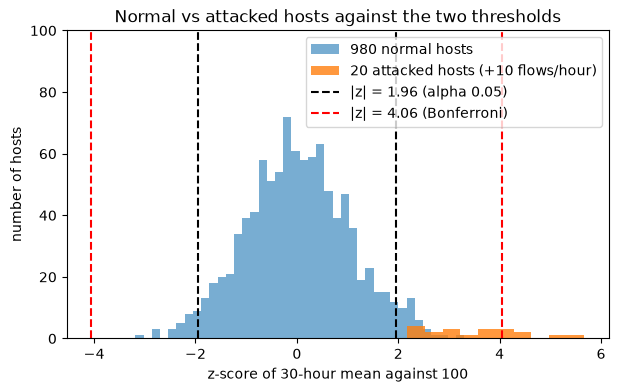

In [38]:
d_crit05 = stats.norm.isf(0.05 / 2)
d_critb = stats.norm.isf(alpha_bonf / 2)
print("normal hosts beyond +1.96:", int((z2[~attacked] > d_crit05).sum()),
      " below -1.96:", int((z2[~attacked] < -d_crit05).sum()))

plt.figure(figsize=(7, 4))
plt.hist(z2[~attacked], bins=40, alpha=0.6, label="980 normal hosts")
plt.hist(z2[attacked], bins=10, alpha=0.8, label="20 attacked hosts (+10 flows/hour)")
for d_sign in (-1, 1):               # the test is two-sided, so each threshold is a pair of lines
    plt.axvline(d_sign * d_crit05, color="k", linestyle="--",
                label="|z| = 1.96 (alpha 0.05)" if d_sign == 1 else None)
    plt.axvline(d_sign * d_critb, color="r", linestyle="--",
                label="|z| = 4.06 (Bonferroni)" if d_sign == 1 else None)
plt.xlabel("z-score of 30-hour mean against 100")
plt.ylabel("number of hosts")
plt.title("Normal vs attacked hosts against the two thresholds")
plt.ylim(0, 100)                     # headroom so the legend does not cover the bars
plt.legend(loc="upper right")
plt.show()

The normal hosts form the familiar bell shape centred on 0, and both of its tails spill past the pair of black 1.96 lines: 39 hosts beyond +1.96 on the right and 25 below -1.96 on the left, which together are the 64 false alarms in the D.3 table. The attacked hosts sit in a short band from 2.18 to 5.67, entirely outside the black lines (so all 20 are caught at 0.05) but straddling the red +4.06 line, with only five beyond it. No normal host gets anywhere near either red line (the most extreme normal z-scores are 3.30 and -3.19), which is why Bonferroni raised no false alarms. In this particular run a pair of lines drawn anywhere between 3.30 and 4.02 would have given zero false alarms and more catches than Bonferroni (between 6 and 11 of the 20), but we only know that because we can see the labels. A real analyst cannot, so what is needed is a rule for placing the lines rather than a lucky guess; the stretch section comes back to this.

### D.5 Trade-off for a team that can investigate twenty alerts a day

The three sentences in the portfolio capture below are the Part D deliverable. They use the seed-0 numbers from D.3: 84 alerts with 20 real at alpha = 0.05, and 5 alerts, all real, under Bonferroni.

**Portfolio capture**

Part D trade-off sentences (1,000 simulated hosts, 20 attacked with +10 flows per hour, seed 0; a team that can investigate twenty alerts a day):

For a team with capacity for twenty investigations a day, the uncorrected alpha = 0.05 rule is unusable: it raises 84 alerts of which only 20 are real (64 false alarms, 23.8% precision), so the analysts would use up their whole day on the first twenty alerts, of which on average only about five would be attacks, while the rest of the queue, real attacks included, goes uninvestigated. The Bonferroni rule (alpha = 0.05 / 1,000) fits the capacity easily, with 5 alerts that are all real and no false alarms, but it lets 15 of the 20 attacks through, so the team feels efficient while missing three quarters of the intrusions. The right threshold is therefore not a statistical constant but a capacity decision, the same precision-versus-detection trade-off as Part C: set the line so that the twenty alerts the team can actually work are as full of real attacks as possible, without giving up so much detection that the exercise becomes pointless.

## Stretch goal - Benjamini-Hochberg and a better model for flow counts

Two loose ends from earlier parts. Part D showed that testing 1,000 hosts at 0.05 each buries 20 real attacks under 64 false alarms, while Bonferroni removes the false alarms but catches only 5 of the 20. Part B showed that a Poisson with the right mean puts almost no probability on the busy normal hours we actually see. Here we try the standard fix for each problem: the Benjamini-Hochberg procedure for the multiple-testing problem, and a negative binomial for the flow counts.

### S.1 Benjamini-Hochberg: controlling the false discovery rate

What the code does: stats.false_discovery_control(p2) turns the 1,000 raw p-values from Part D (20 hosts shifted by +10 flows per hour) into Benjamini-Hochberg adjusted p-values, and we flag a host when its adjusted value is below 0.05. We run the same procedure on the clean p-values p from the no-attack run to see how many false flags it raises when nothing is wrong.

Why we care: Bonferroni asks "what is the chance of even one false alarm across all 1,000 hosts", which is stricter than a SOC needs. BH instead asks "of the hosts we flag, what share do we expect to be false" and holds that at no more than 5%. That is the number an analyst actually lives with: the fraction of a shift's alert queue that turns out to be nothing.

In [39]:
# Benjamini-Hochberg: adjust every p-value so that flagging "adjusted < 0.05"
# keeps the expected share of false flags among the flagged hosts at 5%
p2_adj = stats.false_discovery_control(p2)          # method='bh' is the default
flag_bh = p2_adj < 0.05

# same procedure on the clean run (no attacks) - a false-alarm check
p_adj_clean = stats.false_discovery_control(p)
flag_bh_clean = p_adj_clean < 0.05

print("BH flags on the clean run (no attacks):", int(flag_bh_clean.sum()))
print("BH flags with 20 attacked hosts:       ", int(flag_bh.sum()))
print("  of which real attacks:               ", int((flag_bh & attacked).sum()))
print("  false alarms:                        ", int((flag_bh & ~attacked).sum()))

BH flags on the clean run (no attacks): 0
BH flags with 20 attacked hosts:        11
  of which real attacks:                11
  false alarms:                         0


On the clean run BH flags 0 of the 1,000 hosts, so when nothing is going on it stays quiet, as it usually will (the procedure allows itself a false flag on about 5% of clean runs). With 20 attacked hosts it flags 11, and all 11 are real attacks: zero false alarms, though 9 of the 20 attacks are still missed. Against Part D that is more than double the catches Bonferroni managed (5) with an equally clean alert queue, and nothing like the 84-alert, 64-false-alarm queue the uncorrected 0.05 rule produced.

How BH works, in two sentences. Sort the m = 1,000 p-values from smallest to largest and compare the k-th smallest with k/m times alpha, a line that rises from 0.00005 for k = 1 up to 0.05 for k = 1,000. Find the largest k whose p-value sits at or below its line and flag every host up to and including that k, even if some earlier p-value individually sat above its own line.

What the code does: it redoes that by hand, checks the count agrees with scipy, and shows the first 14 sorted p-values next to their lines so we can see exactly where the cut falls. This is the kind of check that catches a misread of a library's conventions before it ends up in a production detector.

In [40]:
# BH by hand: sort the p-values, compare the k-th smallest with k/m * alpha
m_tests = len(p2)
alpha = 0.05
p_sorted = np.sort(p2)
k = np.arange(1, m_tests + 1)
passes = p_sorted <= k / m_tests * alpha
k_max = int(k[passes].max()) if passes.any() else 0   # largest k that passes
print("largest k with p_(k) <= k/m * alpha:", k_max)
print("same as the number of BH flags above:", k_max == int(flag_bh.sum()))

# the first 14 sorted p-values against their BH lines (3 significant figures)
pd.DataFrame({"k": k[:14],
              "p_(k)": [f"{x:.3g}" for x in p_sorted[:14]],
              "k/m * alpha": [f"{x:.3g}" for x in k[:14] / m_tests * alpha],
              "passes": passes[:14]}).set_index("k")

largest k with p_(k) <= k/m * alpha: 11
same as the number of BH flags above: True


,p_(k),k/m * alpha,passes
k,,,
1,1.4e-08,5e-05,True
2,2.42e-07,0.0001,True
3,4.07e-06,0.00015,True
4,1.37e-05,0.0002,True
5,3.21e-05,0.00025,True
6,5.77e-05,0.0003,True
7,7.7e-05,0.00035,True
8,0.000222,0.0004,True
9,0.000286,0.00045,True


The hand method gives k = 11, the same count scipy produced. Reading the table, the 11th smallest p-value, 0.000437, sits under its line of 0.00055, but the 12th, 0.000974, is above its line of 0.0006 and nothing further down catches up, so the cut falls at 11. Notice how the lines grow: Bonferroni's fixed threshold of 0.00005 is only BH's line for k = 1, and every extra genuinely small p-value raises the bar for the next one. That rising bar is why BH found 11 hosts where Bonferroni, with its single fixed bar, found 5.

What the code does: it builds one table with the three decision rules side by side, recomputing the uncorrected 0.05 and Bonferroni 0.05/1000 rows from p2 so the table stands on its own, then adds the BH row. For each rule it counts alerts, attacks caught out of 20, false alarms and the share of alerts that are real.

Why we care: this is the trade-off a detection engineer has to choose between explicitly. Each rule controls a different error rate, and the table shows what each choice costs in missed attacks and wasted analyst time.

In [41]:
def summarise(flag, name):
    alerts = int(flag.sum())
    caught = int((flag & attacked).sum())
    false_alarms = alerts - caught
    share = caught / alerts if alerts else float("nan")
    return {"rule": name, "alerts": alerts, "attacks caught (of 20)": caught,
            "false alarms": false_alarms, "share of alerts real": round(share, 3)}

rows = [summarise(p2 < 0.05, "uncorrected 0.05"),
        summarise(p2 < 0.05 / 1000, "Bonferroni 0.05/1000"),
        summarise(flag_bh, "Benjamini-Hochberg 0.05")]
bh_table = pd.DataFrame(rows).set_index("rule")
bh_table

,alerts,attacks caught (of 20),false alarms,share of alerts real
rule,,,,
uncorrected 0.05,84,20,64,0.238
Bonferroni 0.05/1000,5,5,0,1.000
Benjamini-Hochberg 0.05,11,11,0,1.000


Uncorrected 0.05 controls the per-test error rate: each of the 980 normal hosts has a 5% chance of a false flag on its own, so about 49 false flags are expected and 64 turned up, giving 84 alerts with all 20 attacks caught but only 0.238 of the alerts real. Bonferroni 0.05/1000 controls the family-wise error rate, the chance of ANY false flag across the whole 1,000 hosts, at 5%: 5 alerts, all real, but 15 attacks missed. Benjamini-Hochberg controls the false discovery rate, the expected share of flagged hosts that are false, at no more than 5%: 11 alerts, all 11 real, 9 missed.

The false discovery rate is the expected value of one minus the "share of alerts real" column, so it is the quantity a SOC cares about: BH promises that, averaged over many runs, no more than 5% of the flagged hosts are false. A single run can sit well below that guarantee, as here where 0 of the 11 flags were false. That makes BH usually the right compromise for a team that can investigate a bounded number of alerts: it spends the alert budget where the evidence is strongest without demanding Bonferroni's near-certainty for every single flag. Comparison with Table 4 of the notes: the values to set beside the table are 84 / 20 / 0.238 (uncorrected), 5 / 5 / 1.000 (Bonferroni) and 11 / 11 / 1.000 (Benjamini-Hochberg) for alerts, attacks caught and share real (Table 4 is in the lecture notes and is not reproduced here). If the notes use a different random seed the counts will differ a little, but the ordering should hold: uncorrected gives many alerts with a low share real, Bonferroni the fewest alerts, and BH in between with a share real at or close to 1.

### S.2 A negative binomial model for the flow counts

What the code does: Part B found the Poisson badly wrong because the variance of normal n_flows is far larger than its mean, and a Poisson forces the two to be equal. The negative binomial has a second parameter that lets the variance exceed the mean, so we fit it to the normal host-hours by the method of moments: with sample mean m and sample variance v, p_nb = m / v and n_nb = m*m / (v - m). This is a moments fit: quick, and it reproduces the mean and variance exactly, but a maximum-likelihood fit would use the whole shape of the data and generally be more accurate. The code also prints where the data and the fitted NB put their peaks, which is a first hint at what a moments fit does and does not capture.

Why we care: the shape of the normal distribution is what sets the false-alarm rate of any threshold detector. If a model's tail matches the data we can set thresholds by calculation for any false-alarm budget, rather than only for the thresholds we happen to have counted.

In [42]:
# method-of-moments negative binomial fit to the normal host-hours
m = flows.mean()
v = flows.var()                 # sample variance (ddof=1)
p_nb = m / v                    # NB success probability
n_nb = m * m / (v - m)          # NB size (number of successes) parameter
print(f"normal host-hours: {len(flows)}")
print(f"mean m           = {m:.3f}")
print(f"variance v       = {v:.3f}")
print(f"variance / mean  = {v / m:.2f}")
print(f"n_nb             = {n_nb:.4f}")
print(f"p_nb             = {p_nb:.5f}")
print(f"NB mean check    = {stats.nbinom.mean(n_nb, p_nb):.3f}, NB variance check = {stats.nbinom.var(n_nb, p_nb):.3f}")
# where each puts its peak: the data versus the fitted NB
ks = np.arange(0, 200)
print(f"data: smallest n_flows = {flows.min()}, most common value = {flows.mode()[0]}, "
      f"share of zero-flow hours = {(flows == 0).mean():.3f}")
print(f"fitted NB: pmf peaks at k = {int(np.argmax(stats.nbinom.pmf(ks, n_nb, p_nb)))}")

normal host-hours: 6728
mean m           = 14.800
variance v       = 204.618
variance / mean  = 13.83
n_nb             = 1.1539
p_nb             = 0.07233
NB mean check    = 14.800, NB variance check = 204.618
data: smallest n_flows = 1, most common value = 6, share of zero-flow hours = 0.000
fitted NB: pmf peaks at k = 1


Across the 6,728 normal host-hours the mean is 14.80 flows and the variance 204.62, a variance-to-mean ratio of 13.83, so a Poisson is out by more than an order of magnitude on variance. The moments fit gives n_nb = 1.154 and p_nb = 0.0723; an n this close to 1 makes the fitted NB nearly geometric, with its pmf peaking at 1 flow and decaying steadily from there. The data do not look like that in the bulk: the smallest count is 1 (no zero-flow hours at all) and the most common value is 6, a hump rather than a slope, so we should expect the moments NB to be a tail approximation more than a fit to the whole shape; the figure below checks. The check line confirms the fitted NB returns the mean 14.800 and variance 204.618 exactly, which a moments fit does by construction, so it says nothing yet about whether the tail is right.

What the code does: for each of Part B's thresholds (30, 45, 60, 100) it computes the counted share of normal hours with n_flows at or above the threshold, what a Poisson with mean m predicts for the same event (sf(T - 1, m)), what the fitted negative binomial predicts (nbinom.sf(T - 1, n_nb, p_nb)), and the absolute error of each model against the counted share. Values are shown to three significant figures so the vanishingly small Poisson tails stay readable.

Why we care: each column is a predicted false-alarm rate for a threshold detector on n_flows. The error columns say how far off a threshold set from that model would be, which is the whole point of having a model.

In [43]:
rows = []
for T in [30, 45, 60, 100]:
    counted = (flows >= T).mean()                    # what the data actually show
    pois = stats.poisson.sf(T - 1, m)                # Poisson P(n_flows >= T)
    nb = stats.nbinom.sf(T - 1, n_nb, p_nb)          # negative binomial P(n_flows >= T)
    rows.append({"threshold": T, "counted share": counted, "Poisson": pois, "NegBin": nb,
                 "Poisson abs error": abs(pois - counted), "NegBin abs error": abs(nb - counted)})
tail_table = pd.DataFrame(rows).set_index("threshold")
tail_table.map(lambda x: f"{x:.3g}")     # 3 significant figures so the tiny Poisson tails stay visible

,counted share,Poisson,NegBin,Poisson abs error,NegBin abs error
threshold,,,,,
30,0.102,0.000338,0.134,0.102,0.032
45,0.0508,2.1e-10,0.0456,0.0508,0.00528
60,0.011,9.72e-19,0.0153,0.011,0.00432
100,0.00372,4.98e-48,0.000814,0.00372,0.0029


At 30 flows the data show 0.102 of normal hours (686 of them); the Poisson says 0.000338 and the NB 0.134, so the NB overstates by about 30% while the Poisson is off by a factor of 300. At 45 the counted share is 0.0508 (342 hours), the Poisson says 2.1e-10 and the NB 0.0456, a slight understatement with an error of 0.0053 against the Poisson's 0.0508. At 60 the counted share is 0.011 (74 hours), the Poisson 9.7e-19 and the NB 0.0153, an overstatement by a factor of about 1.4. At 100 the counted share is 0.00372 (25 hours), the Poisson 5e-48 and the NB 0.000814, an understatement by a factor of about 4.6: roughly 1 in 1,229 predicted against 1 in 269 counted. The NB error is smaller at every threshold, though the gap narrows in the far tail.

What the code does: it draws the density histogram of normal n_flows from Part B (5-flow bins) and overlays the probability mass functions of the Poisson and the fitted negative binomial. Because the histogram is a density and the pmfs are per-integer probabilities, the two are on the same scale and can be compared by eye. The axis stops at 100 flows, so the code also prints how many hours fall off it: the density is normalised over the hours in range, which nudges the bars up by that share.

Why we care: a picture shows at once where each model puts its probability, which the four-row table cannot. A detection engineer choosing a threshold wants to see whether the model's tail sits on top of the data's tail or somewhere else entirely.

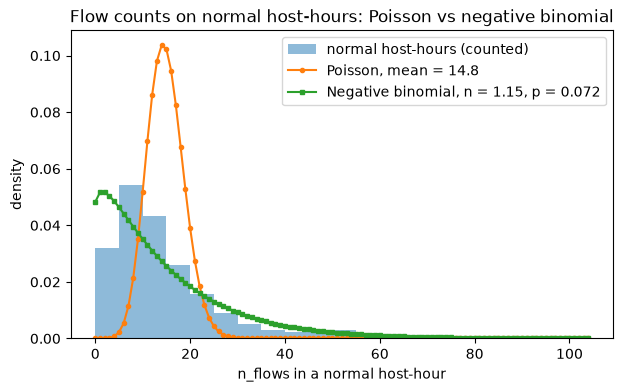

hours above 100 flows, off the axis: 24 of 6728 (0.36%)


In [44]:
ks = np.arange(0, 105)
plt.figure(figsize=(7, 4))
# bins stop at 100, so hours above 100 flows fall off the axis and the density is
# normalised over the rest; a small effect, quantified in the print below
plt.hist(flows, bins=range(0, 105, 5), density=True, alpha=0.5, label="normal host-hours (counted)")
plt.plot(ks, stats.poisson.pmf(ks, m), "o-", ms=3, label=f"Poisson, mean = {m:.1f}")
plt.plot(ks, stats.nbinom.pmf(ks, n_nb, p_nb), "s-", ms=3, label=f"Negative binomial, n = {n_nb:.2f}, p = {p_nb:.3f}")
plt.xlabel("n_flows in a normal host-hour")
plt.ylabel("density")
plt.title("Flow counts on normal host-hours: Poisson vs negative binomial")
plt.legend()
plt.show()
off_axis = int((flows > 100).sum())
print(f"hours above 100 flows, off the axis: {off_axis} of {len(flows)} ({off_axis / len(flows):.2%})")

Verdict: yes, the negative binomial tail matches better than the Poisson at every one of the four thresholds, with absolute errors of 0.032 against 0.102 at 30, 0.0053 against 0.0508 at 45, 0.0043 against 0.011 at 60 and 0.0029 against 0.0037 at 100. The Poisson is a narrow spike around 15 flows and is effectively zero beyond about 30, so any threshold set from it would promise a false-alarm rate wrong by many orders of magnitude; the NB tracks the histogram's tail and stays within a factor of 1.4 of the counted share up to 60. In direction, the NB overstates the tail at 30 (0.134 vs 0.102) and at 60 (0.0153 vs 0.011), understates slightly at 45 (0.0456 vs 0.0508) and understates badly at 100 (0.00081 vs 0.00372). Only 24 of the 6,728 hours (0.36%) fall off the right of the axis, so the bars are on the pmf scale to within that.

The picture also shows that the moments NB is a tail fit, not a bulk fit: with n close to 1 its pmf peaks at 1 flow and falls monotonically, while the data have no zero-flow hours and peak at 6 flows, so the NB curve sits above the 0 to 5 bar and below the 5 to 15 bars. That is the part of the shape a maximum-likelihood fit, which matches the whole pmf rather than two moments, or a shifted NB would be expected to fix.

Why it is only approximate. In cyberlab.py ordinary traffic is generated as 1 + Poisson with a Gamma(2, 6) rate, and a Gamma-Poisson mixture is a negative binomial, so apart from the +1 shift NB is the right family for the bulk. But cyberlab also mixes in busy-admin hours (20 + Poisson(30), about 50 flows, roughly 4% of benign hours) and nightly-backup hours (1 + Poisson(4), about 5 flows, another 4%), so no single NB can be exact. The bigger distortion is one the label-0 subset hides: cyberlab's docstring says the labelling detector misses about 15% of attack hours, so the "normal" hours the fit used contain unlabelled attacks with large flow counts. Those inflate the sample variance the moments fit copies and give the NB a fatter tail than benign traffic really has. The next cell checks this with ground truth.

What the code does: cyberlab can also return what each host-hour really was (true_kind), and its docstring says the labelling detector misses about 15% of attack hours. The code reloads the data with that ground truth, splits the label-0 hours into truly benign hours and unlabelled attacks, repeats the moments fit on the truly benign hours alone, and for each threshold compares the label-0 NB and the benign-only NB with the share of truly benign hours above it.

Why we care: ground truth like this is never available in a real SOC, so we use it only to diagnose the model, not to tune it. If the hours the NB "misses" at 100 flows are not benign at all, and if the attacks hiding in the fitting set also changed the fit, then the model's fault is not what it looked like. The benign-only refit in this cell is likewise a diagnostic: a real SOC could not select training rows by true_kind, so it shows what the label noise cost the fit, not a model we could deploy.

In [45]:
# Peek at ground truth (not available in a real SOC) to see what the far tail really is
Xt = C.load(return_truth=True)                       # same seed, same rows, plus true_kind
normal = Xt[Xt.label == 0]                           # the label-0 hours the NB was fitted to
benign = normal[normal.true_kind == "benign"]        # the ones that really were benign
hidden = normal[normal.true_kind != "benign"]        # attacks the labelling detector missed
print("label-0 hours:", len(normal), " of which truly benign:", len(benign),
      " unlabelled attacks:", len(hidden))
print(f"unlabelled attacks: mean n_flows = {hidden.n_flows.mean():.1f}, max = {hidden.n_flows.max()}")
# the same moments fit on the truly benign hours only
mb, vb = benign.n_flows.mean(), benign.n_flows.var()
p_nb_b = mb / vb
n_nb_b = mb * mb / (vb - mb)
print(f"truly benign only: mean = {mb:.3f}, variance = {vb:.3f}, n_nb = {n_nb_b:.4f}, p_nb = {p_nb_b:.5f}")
print(f"(label-0 fit was:  mean = {m:.3f}, variance = {v:.3f}, n_nb = {n_nb:.4f}, p_nb = {p_nb:.5f})")
rows = []
for T in [30, 45, 60, 100]:
    above = normal[normal.n_flows >= T]
    rows.append({"threshold": T,
                 "label-0 hours >= T": len(above),
                 "truly benign": int((above.true_kind == "benign").sum()),
                 "unlabelled attacks": int((above.true_kind != "benign").sum()),
                 "share of truly benign >= T": round((benign.n_flows >= T).mean(), 5),
                 "NegBin (label-0 fit)": round(stats.nbinom.sf(T - 1, n_nb, p_nb), 5),
                 "NegBin (benign-only fit)": round(stats.nbinom.sf(T - 1, n_nb_b, p_nb_b), 5)})
truth_table = pd.DataFrame(rows).set_index("threshold")
truth_table

label-0 hours: 6728  of which truly benign: 6633  unlabelled attacks: 95
unlabelled attacks: mean n_flows = 67.5, max = 174
truly benign only: mean = 14.045, variance = 135.156, n_nb = 1.6288, p_nb = 0.10392
(label-0 fit was:  mean = 14.800, variance = 204.618, n_nb = 1.1539, p_nb = 0.07233)


,label-0 hours >= T,truly benign,unlabelled attacks,share of truly benign >= T,NegBin (label-0 fit),NegBin (benign-only fit)
threshold,,,,,,
30,686,614,72,0.09257,0.13392,0.10010
45,342,273,69,0.04116,0.04555,0.02370
60,74,22,52,0.00332,0.01532,0.00533
100,25,1,24,0.00015,0.00081,0.00009


Of the 6,728 label-0 hours, 6,633 really were benign and 95 were attacks the labelling detector missed, averaging 67.5 flows (maximum 174) against a benign mean of 14.0. They sit almost entirely in the tail: of the 25 label-0 hours with 100 or more flows, 24 are unlabelled portscans and just 1 is benign, and at 60 or more it is 52 attacks out of 74. So the apparent understatement at 100 was label noise, not a model fault.

Measured against truly benign hours the label-0 NB overstates the tail at every threshold: by 45% at 30 (0.134 vs 0.0926) and 11% at 45 (0.0456 vs 0.0412), but by a factor of 4.6 at 60 (0.0153 vs 0.0033) and 5.4 at 100 (0.00081 vs 0.00015). Most of that pessimism is the fit's own contamination: the 95 unlabelled attacks lift the sample variance from 135.2 (truly benign only) to 204.6, the moments fit copies that variance, and n_nb drops from 1.63 to 1.15, which fattens the tail. Refitting on the truly benign hours alone (n_nb = 1.629, p_nb = 0.104) moves the tail to 0.100 / 0.0237 / 0.0053 / 0.00009 at 30 / 45 / 60 / 100, within a factor of about 1.7 of the truly benign share at 60 and 100, though now 42% low at 45 (0.0237 vs 0.0412), consistent with the busy-admin hours at around 50 flows that a single NB cannot follow. Label noise entered the model through the fit as well as through the counts we compared it with, a theme Topic 10 returns to.

**Portfolio capture**

Benjamini-Hochberg at 0.05 on the 1,000-host experiment flagged 11 hosts, all 11 real attacks and 0 false alarms (share of alerts real 1.000), against 84 alerts with 64 false alarms (0.238 real) for uncorrected 0.05 and 5 alerts, all real, for Bonferroni 0.05/1000; on the clean run BH flagged 0 hosts. It controls the false discovery rate, the expected share of the alert queue that is not real, which is the SOC's own metric, so it is the usual compromise when analysts can work a bounded number of alerts.

A method-of-moments negative binomial fitted to the 6,728 normal host-hours (m = 14.80, v = 204.62, n_nb = 1.154, p_nb = 0.0723) beats the Poisson at every threshold: absolute tail errors of 0.032 / 0.0053 / 0.0043 / 0.0029 at 30 / 45 / 60 / 100 flows versus 0.102 / 0.0508 / 0.011 / 0.0037 for the Poisson, whose tail is effectively zero beyond 30. On the label-0 hours the NB overstates the tail at 30 and 60 and understates it at 45 and 100, but a ground-truth peek shows 24 of the 25 label-0 hours with 100 or more flows are unlabelled portscans (the one benign hour has exactly 100), and that the 95 unlabelled attacks inflate the variance the moments fit copies (204.6 vs 135.2 for truly benign hours); against truly benign traffic the NB is pessimistic at every threshold, mildly at 30 and 45 (45% and 11%) and by a factor of about 5 at 60 and 100. Cleaner labels, not just a maximum-likelihood fit, are what would tighten it, and the moments NB is in any case a tail fit rather than a bulk fit: it peaks at 1 flow where the data peak at 6.

## Summary: what the four questions taught us

**What is normal (Part A).** A normal host-hour on this network has about 11 flows (median), with the middle half of hours between 6 and 18 flows, but the distribution has a long right tail: about 1% of normal hours have 60 or more flows and a few exceed 100. Because of that tail the median and percentiles describe "normal" far better than the mean and standard deviation, and categorical columns such as `top_service` must be counted, never averaged.

**How surprising is it (Part B).** Counting the tail directly is trustworthy: about 1 normal hour in 91 reaches 60 flows, which on 60 hosts is roughly 16 false alarms a day for a 60-flow rule. A Poisson model with the same mean claims the same event is essentially impossible, because real traffic is overdispersed (variance about 14 times the mean). An alert rule built on the wrong model would either fire constantly or lull the analyst into treating common events as impossible. The stretch section shows that a negative binomial, which lets the variance exceed the mean, tracks that tail far better, though label noise in the "normal" hours still distorts the fit.

**Given an alert, is it an attack (Part C).** With attacks at 1 in 5,000, a detector that catches 95% of attacks and false-alarms on 2% of normal hours produces alerts of which fewer than 1% are real. Halving the false-alarm rate nearly doubles that share; raising detection to 99% barely moves it. Assuming a 95%-accurate detector gives 95%-trustworthy alerts is the base-rate fallacy, and the same arithmetic is why precision measured on the module dataset (6.6% attacks) will not transfer to a real network.

**Checking many hosts at once (Part D and stretch).** Testing 1,000 hosts at alpha = 0.05 buys roughly 50 false alarms by construction. Bonferroni removes them but also misses most real anomalies; Benjamini-Hochberg sits in between and directly controls the share of alerts that are false, which is the quantity a security operations team with a fixed investigation budget actually cares about.

**Portfolio deliverables in this notebook:** the Part A hand working, percentile printout and histogram with the "normal hour" sentence; the Part B threshold table and Poisson verdict; the Part C frequency tree, base-rate table and "which change helps more" answer; and the Part D trade-off sentences, plus the stretch-goal comparison table and negative binomial check.